In [37]:
import pandas as pd
import numpy as np

In [38]:
import pandas as pd
from pathlib import Path

# Folder containing the files
folder = Path(r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\raw\Portugal")

# Find all csv files that start with power_samples
files = sorted(folder.glob("power_samples_*.csv"))

dfs = []

for file in files:
    print(f"Reading: {file.name}")
    
    df = pd.read_csv(
        file,
        parse_dates=["tmstp"],   # convert timestamp column
        low_memory=False
    )
    
    dfs.append(df)

# Combine all files
data = pd.concat(dfs, ignore_index=True)

# Sort by timestamp
data = data.sort_values("tmstp").reset_index(drop=True)

print("Final shape:", data.shape)

Reading: power_samples_d1_1.csv
Reading: power_samples_d1_2.csv
Reading: power_samples_d2_1.csv
Reading: power_samples_d2_2.csv
Reading: power_samples_d2_3.csv
Reading: power_samples_d2_4.csv
Reading: power_samples_d2_5.csv
Final shape: (16215480, 19)


In [39]:
data

,iid,tmstp,deploy,Imin,Imax,Iavg,Vmin,Vmax,Vavg,Pmin,Pmax,Pavg,Qmin,Qmax,Qavg,PFmin,PFmax,PFavg,miss_flag
0,7,2010-07-29 00:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,3,2010-07-29 00:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2,2010-07-29 00:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,5,2010-07-29 00:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,8,2010-07-29 00:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16215475,9,2013-02-20 23:55:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
16215476,9,2013-02-20 23:56:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
16215477,9,2013-02-20 23:57:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
16215478,9,2013-02-20 23:58:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [40]:
import pandas as pd

# keep only what you need
df_power = data[["iid", "tmstp", "Pavg"]].copy()

# (optional but recommended) ensure types
df_power["tmstp"] = pd.to_datetime(df_power["tmstp"])
df_power["iid"] = df_power["iid"].astype(int)

# pivot_table tolerates duplicates by aggregating
power_matrix = df_power.pivot_table(
    index="tmstp",
    columns="iid",
    values="Pavg",
    aggfunc="mean"      # or "first" if you prefer
).sort_index()

# optional nicer column names
power_matrix.columns = [f"home_{c}" for c in power_matrix.columns]

power_matrix.head()

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,home_10,...,home_14,home_15,home_16,home_17,home_18,home_19,home_20,home_21,home_22,home_23
tmstp,,,,,,,,,,,,,,,,,,,,,
2010-07-29 12:05:05,NaN,NaN,NaN,NaN,2265.780,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-29 16:22:44,NaN,NaN,NaN,NaN,2466.840,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-29 16:23:44,NaN,NaN,NaN,NaN,933.984,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-29 16:24:44,NaN,NaN,NaN,NaN,2485.220,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-29 16:25:44,NaN,NaN,NaN,NaN,966.414,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
power_matrix

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,home_10,...,home_14,home_15,home_16,home_17,home_18,home_19,home_20,home_21,home_22,home_23
tmstp,,,,,,,,,,,,,,,,,,,,,
2010-07-29 12:05:05,NaN,NaN,NaN,NaN,2265.780,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-29 16:22:44,NaN,NaN,NaN,NaN,2466.840,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-29 16:23:44,NaN,NaN,NaN,NaN,933.984,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-29 16:24:44,NaN,NaN,NaN,NaN,2485.220,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-29 16:25:44,NaN,NaN,NaN,NaN,966.414,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-02-20 14:16:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.85946,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-02-20 14:17:39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.47549,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-02-20 14:18:57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.16343,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
mask_full = power_matrix.notna().all(axis=1)

if mask_full.any():
    first_full_timestamp = power_matrix.index[mask_full][0]
    print("First full timestamp:", first_full_timestamp)
else:
    print("No timestamp where ALL households have data.")

No timestamp where ALL households have data.


In [43]:
available_counts = power_matrix.notna().sum(axis=1)

print("Max simultaneous homes:", int(available_counts.max()))
print("Time range:", power_matrix.index.min(), "→", power_matrix.index.max())

Max simultaneous homes: 8
Time range: 2010-07-29 12:05:05 → 2013-02-20 14:20:53


In [44]:
# Ensure datetime index
power_matrix.index = pd.to_datetime(power_matrix.index)

# Resample to 15 minutes
power_15min = power_matrix.resample("15T").mean()

print(power_15min.shape)
power_15min.head()

C:\Users\CR58XM\AppData\Local\Temp\ipykernel_6752\2031783638.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  power_15min = power_matrix.resample("15T").mean()


(89962, 23)


,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,home_10,...,home_14,home_15,home_16,home_17,home_18,home_19,home_20,home_21,home_22,home_23
tmstp,,,,,,,,,,,,,,,,,,,,,
2010-07-29 12:00:00,NaN,NaN,NaN,NaN,2265.78,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-29 12:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-29 12:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-29 12:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-29 13:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
power_15min

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,home_10,...,home_14,home_15,home_16,home_17,home_18,home_19,home_20,home_21,home_22,home_23
tmstp,,,,,,,,,,,,,,,,,,,,,
2010-07-29 12:00:00,NaN,NaN,NaN,NaN,2265.78,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-29 12:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-29 12:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-29 12:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-29 13:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-02-20 13:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-02-20 13:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-02-20 13:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.078416,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


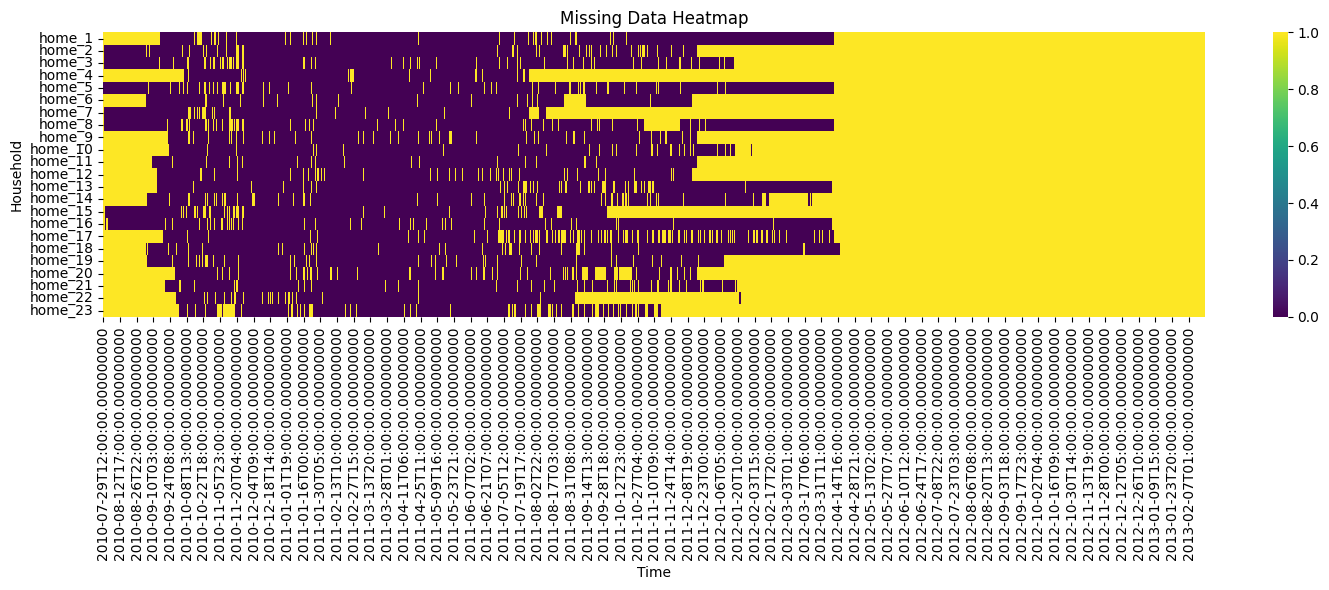

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

sns.heatmap(
    power_15min.isna().T,   # transpose → households on y-axis
    cbar=True,
    cmap="viridis"
)

plt.xlabel("Time")
plt.ylabel("Household")
plt.title("Missing Data Heatmap")
plt.tight_layout()
plt.show()

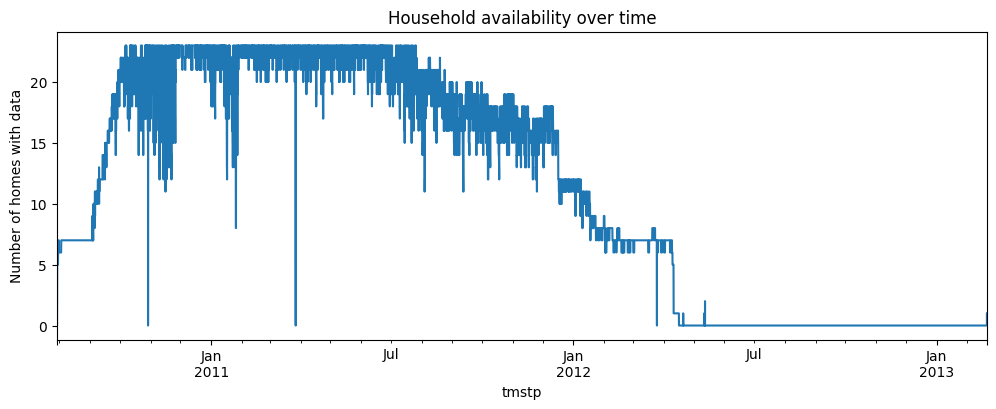

In [47]:
availability = power_15min.notna().sum(axis=1)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
availability.plot()
plt.ylabel("Number of homes with data")
plt.title("Household availability over time")
plt.show()

In [48]:
start = "2010-11-01"
end   = "2011-08-31"

power_selected = power_15min.loc[start:end]

print(power_selected.shape)

(29184, 23)


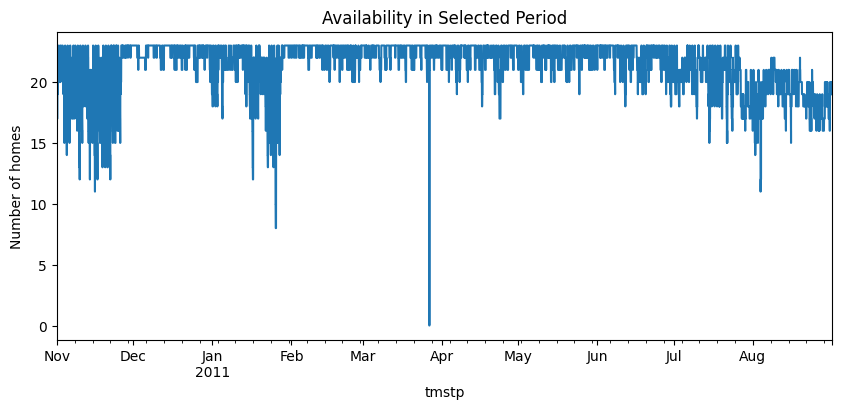

In [49]:
availability_selected = power_selected.notna().sum(axis=1)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
availability_selected.plot()
plt.title("Availability in Selected Period")
plt.ylabel("Number of homes")
plt.show()

<Axes: xlabel='tmstp'>

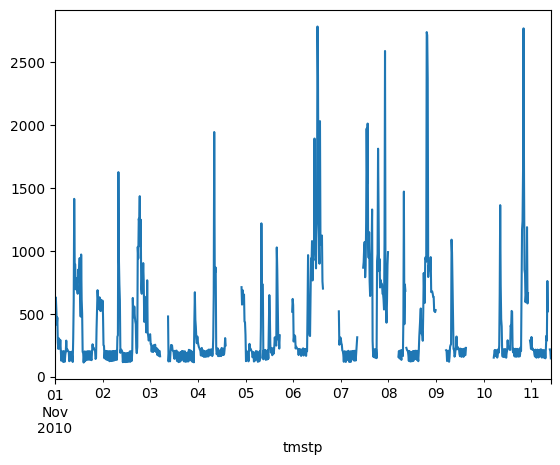

In [50]:
power_selected["home_15"][:1000].plot()

In [51]:
power_selected

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,home_10,...,home_14,home_15,home_16,home_17,home_18,home_19,home_20,home_21,home_22,home_23
tmstp,,,,,,,,,,,,,,,,,,,,,
2010-11-01 00:00:00,NaN,174.967733,NaN,206.481600,224.059867,431.766133,NaN,285.079133,69.192113,170.485427,...,NaN,512.074333,NaN,509.512600,154.098067,1135.811800,433.737800,214.831933,125.345533,783.370600
2010-11-01 00:15:00,NaN,260.121800,NaN,203.839533,314.876467,311.092067,NaN,282.897800,188.308493,142.647260,...,NaN,575.922000,NaN,450.008800,188.447400,1179.575333,397.623600,238.046200,126.120133,662.936867
2010-11-01 00:30:00,NaN,122.849333,NaN,128.006813,333.053333,367.100733,NaN,236.347533,216.103667,90.571807,...,NaN,629.436733,NaN,521.896067,186.902533,1283.650667,217.136267,203.943267,142.713933,528.842733
2010-11-01 00:45:00,NaN,201.994933,NaN,58.625407,276.388200,354.004267,NaN,188.621333,103.018873,90.221360,...,NaN,535.362467,NaN,422.695933,741.144533,1475.178667,246.045000,211.409533,128.093147,646.862533
2010-11-01 01:00:00,NaN,108.709733,NaN,57.947080,206.258067,335.727467,NaN,116.827873,106.090900,92.172593,...,NaN,414.894800,NaN,488.998800,274.901333,1623.536667,205.290867,214.451333,56.279600,470.410733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-08-31 22:45:00,475.466667,439.498500,699.173000,NaN,623.733933,NaN,NaN,110.458800,437.562600,NaN,...,959.948200,567.932467,303.546000,1185.609667,2891.339333,1796.317467,1585.293333,676.508067,235.441133,661.907133
2011-08-31 23:00:00,263.863533,463.187571,677.272000,NaN,462.864867,NaN,NaN,123.752733,215.212357,NaN,...,801.688133,385.728467,344.089200,1061.834214,1622.392308,628.598533,1653.706000,717.779333,294.008600,694.781067
2011-08-31 23:15:00,326.657933,426.502625,699.438067,NaN,523.036733,NaN,NaN,170.010000,303.685967,NaN,...,997.276200,1031.297867,365.244933,861.344800,1289.082308,582.094600,1641.582667,427.690267,244.124400,716.372400


# lets read the weather data

In [52]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

# --- Get start/end from power_selected ---
power_selected.index = pd.to_datetime(power_selected.index)

start_ts = power_selected.index.min()
end_ts   = power_selected.index.max()

start_date = start_ts.strftime("%Y-%m-%d")
end_date   = end_ts.strftime("%Y-%m-%d")

print("Power period:", start_ts, "→", end_ts)
print("Weather API dates:", start_date, "→", end_date)

# --- Setup client (cache forever is fine; you can also use expire_after=3600) ---
cache_session = requests_cache.CachedSession(".cache", expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# --- Historical archive endpoint ---
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 32.6587,
    "longitude": -16.9218,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "wind_speed_10m",
        "precipitation",
        "direct_radiation",
    ],
    "timezone": "UTC",
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]

print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# --- Parse hourly data (order must match params["hourly"]) ---
hourly = response.Hourly()

hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(2).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(3).ValuesAsNumpy()
hourly_direct_radiation = hourly.Variables(4).ValuesAsNumpy()

hourly_index = pd.date_range(
    start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
    end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=hourly.Interval()),
    inclusive="left",
)

weather_hourly = pd.DataFrame(
    {
        "temperature_2m": hourly_temperature_2m,
        "relative_humidity_2m": hourly_relative_humidity_2m,
        "wind_speed_10m": hourly_wind_speed_10m,
        "precipitation": hourly_precipitation,
        "direct_radiation": hourly_direct_radiation,
    },
    index=hourly_index,
)

print("\nWeather hourly head:\n", weather_hourly.head())
print("\nWeather hourly tail:\n", weather_hourly.tail())




# --- Convert to 15-min to match power_selected timestamps ---
weather_15min = weather_hourly.resample("15min").interpolate("time")

power_selected.index = power_selected.index.tz_localize("UTC")

weather_15min_aligned = weather_15min.reindex(power_selected.index)


print("\nWeather 15-min aligned shape:", weather_15min_aligned.shape)

Power period: 2010-11-01 00:00:00 → 2011-08-31 23:45:00
Weather API dates: 2010-11-01 → 2011-08-31
Coordinates: 32.653778076171875°N -16.902435302734375°E
Elevation: 176.0 m asl
Timezone difference to GMT+0: 0s

Weather hourly head:
                            temperature_2m  relative_humidity_2m  \
2010-11-01 00:00:00+00:00       18.917999             68.606644   
2010-11-01 01:00:00+00:00       18.567999             68.761490   
2010-11-01 02:00:00+00:00       18.417999             69.410469   
2010-11-01 03:00:00+00:00       18.268000             70.757561   
2010-11-01 04:00:00+00:00       18.218000             71.212372   

                           wind_speed_10m  precipitation  direct_radiation  
2010-11-01 00:00:00+00:00       12.287555            0.0               0.0  
2010-11-01 01:00:00+00:00       11.983188            0.0               0.0  
2010-11-01 02:00:00+00:00       12.287555            0.0               0.0  
2010-11-01 03:00:00+00:00       12.481153            0.

In [53]:
data_merged = power_selected.join(weather_15min_aligned, how="left")

print(data_merged.shape)
data_merged.head()

(29184, 28)


,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,home_10,...,home_19,home_20,home_21,home_22,home_23,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,direct_radiation
tmstp,,,,,,,,,,,,,,,,,,,,,
2010-11-01 00:00:00+00:00,NaN,174.967733,NaN,206.481600,224.059867,431.766133,NaN,285.079133,69.192113,170.485427,...,1135.811800,433.737800,214.831933,125.345533,783.370600,18.917999,68.606644,12.287555,0.0,0.0
2010-11-01 00:15:00+00:00,NaN,260.121800,NaN,203.839533,314.876467,311.092067,NaN,282.897800,188.308493,142.647260,...,1179.575333,397.623600,238.046200,126.120133,662.936867,18.830500,68.645355,12.211463,0.0,0.0
2010-11-01 00:30:00+00:00,NaN,122.849333,NaN,128.006813,333.053333,367.100733,NaN,236.347533,216.103667,90.571807,...,1283.650667,217.136267,203.943267,142.713933,528.842733,18.743000,68.684067,12.135371,0.0,0.0
2010-11-01 00:45:00+00:00,NaN,201.994933,NaN,58.625407,276.388200,354.004267,NaN,188.621333,103.018873,90.221360,...,1475.178667,246.045000,211.409533,128.093147,646.862533,18.655499,68.722778,12.059279,0.0,0.0
2010-11-01 01:00:00+00:00,NaN,108.709733,NaN,57.947080,206.258067,335.727467,NaN,116.827873,106.090900,92.172593,...,1623.536667,205.290867,214.451333,56.279600,470.410733,18.567999,68.761490,11.983188,0.0,0.0


In [54]:
data_merged

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,home_10,...,home_19,home_20,home_21,home_22,home_23,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,direct_radiation
tmstp,,,,,,,,,,,,,,,,,,,,,
2010-11-01 00:00:00+00:00,NaN,174.967733,NaN,206.481600,224.059867,431.766133,NaN,285.079133,69.192113,170.485427,...,1135.811800,433.737800,214.831933,125.345533,783.370600,18.917999,68.606644,12.287555,0.0,0.0
2010-11-01 00:15:00+00:00,NaN,260.121800,NaN,203.839533,314.876467,311.092067,NaN,282.897800,188.308493,142.647260,...,1179.575333,397.623600,238.046200,126.120133,662.936867,18.830500,68.645355,12.211463,0.0,0.0
2010-11-01 00:30:00+00:00,NaN,122.849333,NaN,128.006813,333.053333,367.100733,NaN,236.347533,216.103667,90.571807,...,1283.650667,217.136267,203.943267,142.713933,528.842733,18.743000,68.684067,12.135371,0.0,0.0
2010-11-01 00:45:00+00:00,NaN,201.994933,NaN,58.625407,276.388200,354.004267,NaN,188.621333,103.018873,90.221360,...,1475.178667,246.045000,211.409533,128.093147,646.862533,18.655499,68.722778,12.059279,0.0,0.0
2010-11-01 01:00:00+00:00,NaN,108.709733,NaN,57.947080,206.258067,335.727467,NaN,116.827873,106.090900,92.172593,...,1623.536667,205.290867,214.451333,56.279600,470.410733,18.567999,68.761490,11.983188,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-08-31 22:45:00+00:00,475.466667,439.498500,699.173000,NaN,623.733933,NaN,NaN,110.458800,437.562600,NaN,...,1796.317467,1585.293333,676.508067,235.441133,661.907133,21.480499,83.308701,12.354119,0.0,0.0
2011-08-31 23:00:00+00:00,263.863533,463.187571,677.272000,NaN,462.864867,NaN,NaN,123.752733,215.212357,NaN,...,628.598533,1653.706000,717.779333,294.008600,694.781067,21.417999,83.561340,12.475961,0.0,0.0
2011-08-31 23:15:00+00:00,326.657933,426.502625,699.438067,NaN,523.036733,NaN,NaN,170.010000,303.685967,NaN,...,582.094600,1641.582667,427.690267,244.124400,716.372400,NaN,NaN,NaN,NaN,NaN


In [55]:
data_merged.index = data_merged.index.tz_convert(None)

In [56]:
data_merged

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,home_10,...,home_19,home_20,home_21,home_22,home_23,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,direct_radiation
tmstp,,,,,,,,,,,,,,,,,,,,,
2010-11-01 00:00:00,NaN,174.967733,NaN,206.481600,224.059867,431.766133,NaN,285.079133,69.192113,170.485427,...,1135.811800,433.737800,214.831933,125.345533,783.370600,18.917999,68.606644,12.287555,0.0,0.0
2010-11-01 00:15:00,NaN,260.121800,NaN,203.839533,314.876467,311.092067,NaN,282.897800,188.308493,142.647260,...,1179.575333,397.623600,238.046200,126.120133,662.936867,18.830500,68.645355,12.211463,0.0,0.0
2010-11-01 00:30:00,NaN,122.849333,NaN,128.006813,333.053333,367.100733,NaN,236.347533,216.103667,90.571807,...,1283.650667,217.136267,203.943267,142.713933,528.842733,18.743000,68.684067,12.135371,0.0,0.0
2010-11-01 00:45:00,NaN,201.994933,NaN,58.625407,276.388200,354.004267,NaN,188.621333,103.018873,90.221360,...,1475.178667,246.045000,211.409533,128.093147,646.862533,18.655499,68.722778,12.059279,0.0,0.0
2010-11-01 01:00:00,NaN,108.709733,NaN,57.947080,206.258067,335.727467,NaN,116.827873,106.090900,92.172593,...,1623.536667,205.290867,214.451333,56.279600,470.410733,18.567999,68.761490,11.983188,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-08-31 22:45:00,475.466667,439.498500,699.173000,NaN,623.733933,NaN,NaN,110.458800,437.562600,NaN,...,1796.317467,1585.293333,676.508067,235.441133,661.907133,21.480499,83.308701,12.354119,0.0,0.0
2011-08-31 23:00:00,263.863533,463.187571,677.272000,NaN,462.864867,NaN,NaN,123.752733,215.212357,NaN,...,628.598533,1653.706000,717.779333,294.008600,694.781067,21.417999,83.561340,12.475961,0.0,0.0
2011-08-31 23:15:00,326.657933,426.502625,699.438067,NaN,523.036733,NaN,NaN,170.010000,303.685967,NaN,...,582.094600,1641.582667,427.690267,244.124400,716.372400,NaN,NaN,NaN,NaN,NaN


# imputer

In [57]:
import os
import shutil
from typing import List, Tuple, Optional
from pathlib import Path
from typing import List
import pandas as pd
import lightgbm

def imputer(df, target_columns=None, lgbm_params=None):
    """
    Impute missing values in a time-series Series or DataFrame.
    Here we apply a linearly interpolation on 2 consecutive NaNs or fewer.
    If there is a larger chunk of NaNs then we use a LightGBM regressor to fill in longer missing intervals.

    Parameters
    ----------
    df : pd.Series or pd.DataFrame
        A pandas Series or DataFrame with a DatetimeIndex.
    target_columns : list or None
        Which columns to impute. If None, all columns with NaNs will be imputed.
        (Ignored if df is a Series, because there's only one column.)
    lgbm_params : dict or None
        Parameters for the LGBMRegressor. If None, defaults are used.

    Returns
    -------
    pd.Series or pd.DataFrame
        The same type as `df`, with missing values imputed.
    """
    # Check if input is a Series
    was_series = False
    original_name = None
    if isinstance(df, pd.Series):
        was_series = True
        original_name = df.name if df.name is not None else "value"
        df = df.to_frame(name=original_name)
    
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame/Series must have a DatetimeIndex.")
    
    # Identify columns needing imputation
    if target_columns is None:
        target_columns = [col for col in df.columns if df[col].isna().any()]
    
    # First pass: linearly interpolate small gaps (<= 2 consecutive NaNs)
    for col in target_columns:
        small_gaps = df[col].isna().astype(int).groupby(df[col].notna().cumsum()).sum()
        if any((small_gaps <= 2) & (small_gaps > 0)):
            print(f"Column '{col}' has small gaps (<= 2 consecutive NaNs).")
    df[target_columns] = df[target_columns].interpolate(method='linear', limit=2)
    
    # Default LightGBM parameters if none provided
    if lgbm_params is None:
        lgbm_params = {
            'n_estimators': 500,
            'learning_rate': 0.1,
            'random_state': 42
        }

    # Create time-based features
    global_time_features = pd.DataFrame(index=df.index)
    global_time_features['minute'] = df.index.minute
    global_time_features['hour'] = df.index.hour
    global_time_features['day'] = df.index.day
    global_time_features['dayofweek'] = df.index.dayofweek
    global_time_features['month'] = df.index.month

    #LightGBM for larger gaps
    for target in target_columns:
        # Check if there are still missing values after small-gap interpolation
        if not df[target].isna().any():
            continue 
        print(f"Column '{target}' has large gaps (> 2 consecutive NaNs).")

        # we only train the model on rows for which the target column has non‐missing values
        not_null_mask = df[target].notna()
        y_train = df.loc[not_null_mask, target]

        # Build training features
        other_cols = df.columns.difference([target])
        X_train = pd.concat([df.loc[not_null_mask, other_cols],
                             global_time_features.loc[not_null_mask]], axis=1)

        # Train LightGBM
        model = lightgbm.LGBMRegressor(**lgbm_params,verbose=-1)
        model.fit(X_train, y_train)

        # Predict for the missing rows
        null_mask = df[target].isna()
        if null_mask.any():
            X_missing = pd.concat([df.loc[null_mask, other_cols],
                                   global_time_features.loc[null_mask]], axis=1)
            df.loc[null_mask, target] = model.predict(X_missing)

    if was_series:
        col_name = df.columns[0]
        df_series = df[col_name]
        df_series.name = original_name
        return df_series

    return df

def feature_correlation_sorter_and_remover(df: pd.DataFrame, target: str, threshold: float = 0.1) -> pd.Series:
    """
    This function sorts the features based on their correlation with the target 
    and removes the ones that are below the threshold.
    
    Parameters:
        df (pd.DataFrame): The DataFrame with the features and the target column.
        target (str): The name of the target column.
        threshold (float): The threshold for the correlation (default is 0.1).
    
    Returns:
        pd.Series: The features (rows) that are above the threshold and their correlation with the target.
    """
    # Compute correlation with the target column
    correlation_with_target = df.corr(method="pearson")[target].abs()
    
    # Sort features by correlation values in descending order
    sorted_features = correlation_with_target.sort_values(ascending=False)
    
    # Filter features based on the threshold
    filtered_features = sorted_features[sorted_features >= threshold]

    # Return the filtered and sorted features with their correlations
    return filtered_features.drop(target, errors='ignore')


def list_creator_flagger(
    df: pd.DataFrame, 
    substrings: Optional[List[str]] = None
) -> Tuple[List[str], List[str]]:
    """
    Separates DataFrame columns into two lists: those containing specified substrings 
    and those that do not.

    Parameters:
        df (pd.DataFrame): The DataFrame with the features.
        substrings (List[str], optional): The list of substrings to search for in column names.
            Default is ['flag', 'cos', 'sin', 'day_of_week', 'day_of_month', 'weekend', 
                       'days_in_month', 'hour', 'minute'].

    Returns:
        - non_flag_columns (List[str]): Columns that do not contain the specified substrings.
        - flag_columns (List[str]): Columns that contain the specified substrings.
    """
    if substrings is None:
        substrings = [
            'flag', 'cos', 'sin', 'day_of_week', 'day_of_month', 
            'weekend', 'days_in_month', 'hour', 'minute'
        ]

    flag_columns = [col for col in df.columns if any(substring in col for substring in substrings)]

    if not flag_columns:
        print("No columns with the specified substrings found.")
        return [], []

    non_flag_columns = [col for col in df.columns if col not in flag_columns]

    return non_flag_columns, flag_columns

def empty_folder(folder: str) -> None:
    """
    Empties a folder by deleting all its contents. If the folder does not exist, it creates it.

    Args:
        folder (str): The path to the folder to be emptied.
    """
    # Get the absolute path of the folder
    absolute_folder_path = os.path.abspath(folder)
    print(f"Attempting to empty folder: {absolute_folder_path}")
    
    # Check if the directory exists; create it if not
    if not os.path.exists(absolute_folder_path):
        os.makedirs(absolute_folder_path)  # Creates the folder if it doesn't exist
        print(f"Folder did not exist and was created: {absolute_folder_path}")
        return  # Exit after creating, no need to empty

    print(f"Folder exists and will be emptied: {absolute_folder_path}")
        
    # Iterate over the items in the directory
    for item in os.listdir(absolute_folder_path):
        item_path = os.path.join(absolute_folder_path, item)
        print(f"Processing item: {item_path}")
        
        # Delete file or directory
        try:
            if os.path.isfile(item_path):
                os.remove(item_path)
                print(f"Deleted file: {item_path}")
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)
                print(f"Deleted directory: {item_path}")
        except Exception as e:
            print(f"Error deleting {item_path}: {e}")
    
    print(f"The folder '{folder}' has been emptied.")

def save_best_params_to_csv(study, path: str, hours: int) -> None:
    """
    Save the best parameters from an Optuna study to a CSV file in the 'models' directory.
    Every time the function is called, it appends the new data to the existing CSV file.

    Args:
        study: Optuna study object containing the best parameters and trial results.
        path (str): Base path where the 'models' folder is located.
        hours (int): Multiplication factor for 'hours_in'.
    """
    # Extract best parameters and additional information
    best_params = study.best_params.copy()
    best_params["mse"] = study.best_trial.value
    best_params["trials"] = len(study.trials)
    best_params['hours_in'] *= hours  # Convert back to points

    # Handle `fc_layers` (convert to string for saving)
    fc_layers = [
        best_params.pop(f"fc_layer_{i+1}", None) for i in range(best_params.get("n_layers", 0))
    ]
    best_params["fc_layers"] = ",".join(map(str, fc_layers))  # Save as comma-separated string

    # Define the column names
    columns = [
        'hours_in', 'hours_out', 'suggested_hidden_dim', 'n_rnn_layers',
        'dropout', 'lr','fc_layers', 'mse', 'trials'
    ]

    # Create a DataFrame for the best parameters
    best_params_df = pd.DataFrame([best_params])

    # Define the file path
    target_dir = Path(path) / 'models'
    hyper_params_filepath = target_dir / "hyper_params_df.csv"
    print(f"Saving to file: {hyper_params_filepath}")

    # Check if the file exists
    if hyper_params_filepath.is_file():
        # Read the existing file
        existing_df = pd.read_csv(hyper_params_filepath)
        print("File exists. Appending data.")
        
        if set(columns).issubset(existing_df.columns):
            # Append new data to existing DataFrame
            updated_df = pd.concat([existing_df, best_params_df], ignore_index=True)
        else:
            print("Warning: CSV columns do not match expected columns. Columns will be reset.")
            # Create a new DataFrame with the correct columns
            updated_df = pd.DataFrame(columns=columns)
            updated_df = pd.concat([updated_df, best_params_df], ignore_index=True)
    else:
        print("File does not exist. Creating new file.")
        # Create a new DataFrame with the correct columns
        updated_df = pd.DataFrame(columns=columns)
        updated_df = pd.concat([updated_df, best_params_df], ignore_index=True)

    # Save the DataFrame to CSV
    updated_df.to_csv(hyper_params_filepath, index=False)
    print("Data saved successfully.")
    
def read_hyper_params(path: str) -> dict:
    """
    Reads the hyperparameters from the CSV file and returns the last line as a dictionary.

    Args:
        path (str): The path to the folder where the models are stored.

    Returns:
        dict: The last line of the CSV file as a dictionary.
    
    Raises:
        ValueError: If the CSV file is empty.
    """
    # Define the path to the CSV file
    path_csv = Path(path) / "models" / "hyper_params_df.csv"
    
    # Read the CSV file into a DataFrame
    df = pd.read_csv(path_csv)
    
    if df.empty:
        raise ValueError("The CSV file is empty.")
    
    # Get the last row as a Series
    last_line = df.iloc[-1]
    
    # Convert the Series to a dictionary
    last_line_dict = last_line.to_dict()
    
    # Process `fc_layers` (convert back to a list of integers)
    if "fc_layers" in last_line_dict:
        last_line_dict["fc_layers"] = list(map(int, last_line_dict["fc_layers"].split(",")))

    # Define the keys that should not be converted to int
    exclude_from_int_conversion = {"dropout", "lr", "fc_layers"}
    
    # Process the dictionary
    processed_dict = {}
    for key, value in last_line_dict.items():
        if key in exclude_from_int_conversion:
            processed_dict[key] = value
        else:
            try:
                processed_dict[key] = int(value)
            except (ValueError, TypeError):
                processed_dict[key] = value
    
    return processed_dict

def separate_past_and_future_features(ordered_features_list):
    """
    Separates features into past and future covariates based on specific conditions.

    Args:
        ordered_features_list (list of str): List of feature names in the desired order.

    Returns:
        tuple: A tuple containing two lists:
            - past_covariates (list of str): Features considered as past covariates.
            - future_covariates (list of str): Features considered as future covariates.
    """
    past_covariates = []
    future_covariates = []
    
    future_condition_strings = [
        "sin", "cos", "hour", "flag", "day", "month", "week",
        "weekend", "day_of_week", "day_of_month", "days_in_month",
        "minute"
    ]
    
    for feature in ordered_features_list:
        if any(condition_string in feature for condition_string in future_condition_strings):
            future_covariates.append(feature)
        else:
            past_covariates.append(feature)
    
    return past_covariates, future_covariates



My imputer() uses other columns as features. If those other columns still contain NaNs in the rows you’re predicting, LightGBM may error or behave badly. So it’s best to impute in a safe order:

impute weather first (almost no gaps)

then impute households using weather + time features (and optionally other homes)

In [58]:
home_cols = [c for c in data_merged.columns if c.startswith("home_")]
weather_cols = ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "precipitation", "direct_radiation"]

data_imp = data_merged.copy()

# Impute weather only first
data_imp[weather_cols] = imputer(
    data_imp[weather_cols],
    target_columns=weather_cols
)

data_imp = data_merged.copy()

# Impute weather only first
data_imp[weather_cols] = imputer(
    data_imp[weather_cols],
    target_columns=weather_cols
)

data_imp_homes = data_imp.copy()

for col in home_cols:
    print(f"\nImputing {col} ...")
    tmp = pd.concat([data_imp_homes[[col]], data_imp_homes[weather_cols]], axis=1)
    tmp_imputed = imputer(tmp, target_columns=[col])
    data_imp_homes[col] = tmp_imputed[col]
    
data_imp = data_imp_homes

Column 'temperature_2m' has large gaps (> 2 consecutive NaNs).


C:\Users\CR58XM\AppData\Local\Temp\ipykernel_6752\267620176.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[target_columns] = df[target_columns].interpolate(method='linear', limit=2)
C:\Users\CR58XM\AppData\Local\Temp\ipykernel_6752\267620176.py:93: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[22.16422499]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df.loc[null_mask, target] = model.predict(X_missing)


Column 'relative_humidity_2m' has large gaps (> 2 consecutive NaNs).


C:\Users\CR58XM\AppData\Local\Temp\ipykernel_6752\267620176.py:93: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[88.31757303]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df.loc[null_mask, target] = model.predict(X_missing)


Column 'wind_speed_10m' has large gaps (> 2 consecutive NaNs).


...

Column 'precipitation' has large gaps (> 2 consecutive NaNs).


C:\Users\CR58XM\AppData\Local\Temp\ipykernel_6752\267620176.py:93: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.00034105]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df.loc[null_mask, target] = model.predict(X_missing)


Column 'direct_radiation' has large gaps (> 2 consecutive NaNs).


C:\Users\CR58XM\AppData\Local\Temp\ipykernel_6752\267620176.py:93: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[5.23608235]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df.loc[null_mask, target] = model.predict(X_missing)



Imputing home_1 ...
Column 'home_1' has small gaps (<= 2 consecutive NaNs).
Column 'home_1' has large gaps (> 2 consecutive NaNs).

Imputing home_2 ...
Column 'home_2' has small gaps (<= 2 consecutive NaNs).
Column 'home_2' has large gaps (> 2 consecutive NaNs).

Imputing home_3 ...
Column 'home_3' has large gaps (> 2 consecutive NaNs).

Imputing home_4 ...
Column 'home_4' has large gaps (> 2 consecutive NaNs).

Imputing home_5 ...
Column 'home_5' has small gaps (<= 2 consecutive NaNs).
Column 'home_5' has large gaps (> 2 consecutive NaNs).

Imputing home_6 ...
Column 'home_6' has large gaps (> 2 consecutive NaNs).

Imputing home_7 ...
Column 'home_7' has small gaps (<= 2 consecutive NaNs).
Column 'home_7' has large gaps (> 2 consecutive NaNs).

Imputing home_8 ...
Column 'home_8' has small gaps (<= 2 consecutive NaNs).
Column 'home_8' has large gaps (> 2 consecutive NaNs).

Imputing home_9 ...
Column 'home_9' has small gaps (<= 2 consecutive NaNs).
Column 'home_9' has large gaps (> 2

In [59]:
print("Missing values after imputation (%):")
print((data_imp.isna().mean() * 100).sort_values(ascending=False).head(15))

Missing values after imputation (%):
home_1     0.0
home_2     0.0
home_3     0.0
home_4     0.0
home_5     0.0
home_6     0.0
home_7     0.0
home_8     0.0
home_9     0.0
home_10    0.0
home_11    0.0
home_12    0.0
home_13    0.0
home_14    0.0
home_15    0.0
dtype: float64


<Axes: xlabel='tmstp'>

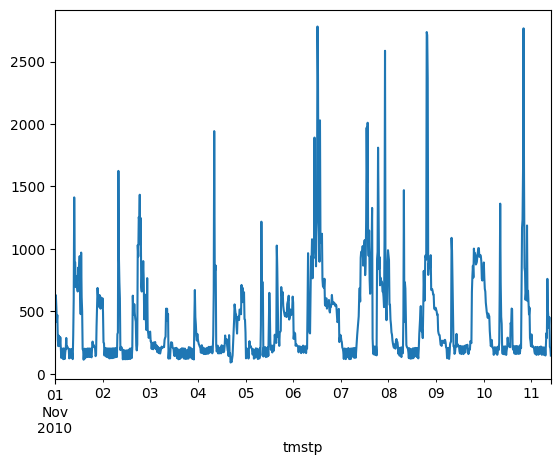

In [60]:
data_imp["home_15"][:1000].plot()

In [61]:
data_imp

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,home_10,...,home_19,home_20,home_21,home_22,home_23,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,direct_radiation
tmstp,,,,,,,,,,,,,,,,,,,,,
2010-11-01 00:00:00,457.472866,174.967733,492.099224,206.481600,224.059867,431.766133,73.694601,285.079133,69.192113,170.485427,...,1135.811800,433.737800,214.831933,125.345533,783.370600,18.917999,68.606644,12.287555,0.000000,0.000000
2010-11-01 00:15:00,500.801333,260.121800,470.798278,203.839533,314.876467,311.092067,75.061727,282.897800,188.308493,142.647260,...,1179.575333,397.623600,238.046200,126.120133,662.936867,18.830500,68.645355,12.211463,0.000000,0.000000
2010-11-01 00:30:00,370.633780,122.849333,407.156967,128.006813,333.053333,367.100733,80.920355,236.347533,216.103667,90.571807,...,1283.650667,217.136267,203.943267,142.713933,528.842733,18.743000,68.684067,12.135371,0.000000,0.000000
2010-11-01 00:45:00,301.605054,201.994933,350.498340,58.625407,276.388200,354.004267,83.212884,188.621333,103.018873,90.221360,...,1475.178667,246.045000,211.409533,128.093147,646.862533,18.655499,68.722778,12.059279,0.000000,0.000000
2010-11-01 01:00:00,566.303485,108.709733,371.745099,57.947080,206.258067,335.727467,74.740574,116.827873,106.090900,92.172593,...,1623.536667,205.290867,214.451333,56.279600,470.410733,18.567999,68.761490,11.983188,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-08-31 22:45:00,475.466667,439.498500,699.173000,219.873629,623.733933,-14.709006,77.899092,110.458800,437.562600,1195.059518,...,1796.317467,1585.293333,676.508067,235.441133,661.907133,21.480499,83.308701,12.354119,0.000000,0.000000
2011-08-31 23:00:00,263.863533,463.187571,677.272000,192.842971,462.864867,18.013766,83.241530,123.752733,215.212357,1043.483026,...,628.598533,1653.706000,717.779333,294.008600,694.781067,21.417999,83.561340,12.475961,0.000000,0.000000
2011-08-31 23:15:00,326.657933,426.502625,699.438067,186.517262,523.036733,2.601520,81.443211,170.010000,303.685967,1045.686669,...,582.094600,1641.582667,427.690267,244.124400,716.372400,21.417999,83.561340,12.475961,0.000000,0.000000


In [64]:
negative_per_house = (data_imp < 0).sum()
print(negative_per_house)

home_1                    6
home_2                    0
home_3                    0
home_4                    0
home_5                    0
home_6                  348
home_7                  360
home_8                    0
home_9                    0
home_10                   0
home_11                   0
home_12                   0
home_13                   0
home_14                   0
home_15                   0
home_16                   1
home_17                   1
home_18                  14
home_19                   0
home_20                   0
home_21                   0
home_22                   0
home_23                   0
temperature_2m            0
relative_humidity_2m      0
wind_speed_10m            0
precipitation             0
direct_radiation          0
dtype: int64


In [65]:
neg_positions = (
    data_imp[data_imp < 0]
    .stack()
    .reset_index()
)

neg_positions.columns = ["timestamp", "house", "value"]

print(neg_positions)

              timestamp    house       value
0   2010-12-28 23:15:00  home_18   -5.208205
1   2010-12-28 23:30:00  home_18  -17.403196
2   2010-12-28 23:45:00  home_18  -90.159259
3   2011-01-22 15:45:00  home_18 -106.404209
4   2011-01-22 16:00:00  home_18  -69.577023
..                  ...      ...         ...
725 2011-08-31 18:30:00   home_6  -16.617425
726 2011-08-31 22:30:00   home_6  -16.610110
727 2011-08-31 22:45:00   home_6  -14.709006
728 2011-08-31 23:30:00   home_6  -11.336309
729 2011-08-31 23:45:00   home_6 -124.165162

[730 rows x 3 columns]


In [68]:
data_imp[data_imp < 0] = 0

In [69]:
neg_positions = (
    data_imp[data_imp < 0]
    .stack()
    .reset_index()
)

neg_positions.columns = ["timestamp", "house", "value"]

print(neg_positions)

Empty DataFrame
Columns: [timestamp, house, value]
Index: []


In [72]:
data_imp

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,home_10,...,home_19,home_20,home_21,home_22,home_23,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,direct_radiation
timestamp,,,,,,,,,,,,,,,,,,,,,
2010-11-01 00:00:00,457.472866,174.967733,492.099224,206.481600,224.059867,431.766133,73.694601,285.079133,69.192113,170.485427,...,1135.811800,433.737800,214.831933,125.345533,783.370600,18.917999,68.606644,12.287555,0.000000,0.000000
2010-11-01 00:15:00,500.801333,260.121800,470.798278,203.839533,314.876467,311.092067,75.061727,282.897800,188.308493,142.647260,...,1179.575333,397.623600,238.046200,126.120133,662.936867,18.830500,68.645355,12.211463,0.000000,0.000000
2010-11-01 00:30:00,370.633780,122.849333,407.156967,128.006813,333.053333,367.100733,80.920355,236.347533,216.103667,90.571807,...,1283.650667,217.136267,203.943267,142.713933,528.842733,18.743000,68.684067,12.135371,0.000000,0.000000
2010-11-01 00:45:00,301.605054,201.994933,350.498340,58.625407,276.388200,354.004267,83.212884,188.621333,103.018873,90.221360,...,1475.178667,246.045000,211.409533,128.093147,646.862533,18.655499,68.722778,12.059279,0.000000,0.000000
2010-11-01 01:00:00,566.303485,108.709733,371.745099,57.947080,206.258067,335.727467,74.740574,116.827873,106.090900,92.172593,...,1623.536667,205.290867,214.451333,56.279600,470.410733,18.567999,68.761490,11.983188,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-08-31 22:45:00,475.466667,439.498500,699.173000,219.873629,623.733933,0.000000,77.899092,110.458800,437.562600,1195.059518,...,1796.317467,1585.293333,676.508067,235.441133,661.907133,21.480499,83.308701,12.354119,0.000000,0.000000
2011-08-31 23:00:00,263.863533,463.187571,677.272000,192.842971,462.864867,18.013766,83.241530,123.752733,215.212357,1043.483026,...,628.598533,1653.706000,717.779333,294.008600,694.781067,21.417999,83.561340,12.475961,0.000000,0.000000
2011-08-31 23:15:00,326.657933,426.502625,699.438067,186.517262,523.036733,2.601520,81.443211,170.010000,303.685967,1045.686669,...,582.094600,1641.582667,427.690267,244.124400,716.372400,21.417999,83.561340,12.475961,0.000000,0.000000


In [70]:
output_path = r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\dataset_Portugal.csv"

data_imp.index.name = "timestamp"   # optional but good practice
data_imp.to_csv(output_path, index=True)

print("Saved to:", output_path)

Saved to: C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\dataset_Portugal.csv
